In [3]:
# HW 8 STAT 604 Duncan Newman

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("mouse.csv")

# Extract weights (adjust column name if needed)
weights = df["Weight2"].dropna().values

In [4]:
# Parameters
n = 30
B = 5000

# Step 1: Sample with replacement
sample = np.random.choice(weights, size=n, replace=True)
mu = np.mean(sample)
s = np.std(sample, ddof=1)

# Step 2 & 3: Generate bootstrap means
bootstrap_means_param = []

for _ in range(B):
    simulated = np.random.normal(loc=mu, scale=s, size=n)
    bootstrap_means_param.append(np.mean(simulated))

bootstrap_means_param = np.array(bootstrap_means_param)

# Step 4: Percentiles
lower_param = np.percentile(bootstrap_means_param, 12.5)
upper_param = np.percentile(bootstrap_means_param, 87.5)

print("Parametric 75% CI:", (lower_param, upper_param))

Parametric 75% CI: (np.float64(30.93572161863473), np.float64(33.32520237415082))


In [5]:
bootstrap_means_nonparam = []

for _ in range(B):
    sample = np.random.choice(weights, size=n, replace=True)
    bootstrap_means_nonparam.append(np.mean(sample))

bootstrap_means_nonparam = np.array(bootstrap_means_nonparam)

# Percentiles
lower_nonparam = np.percentile(bootstrap_means_nonparam, 12.5)
upper_nonparam = np.percentile(bootstrap_means_nonparam, 87.5)

print("Nonparametric 75% CI:", (lower_nonparam, upper_nonparam))

Nonparametric 75% CI: (np.float64(32.04004166666666), np.float64(35.19416666666667))


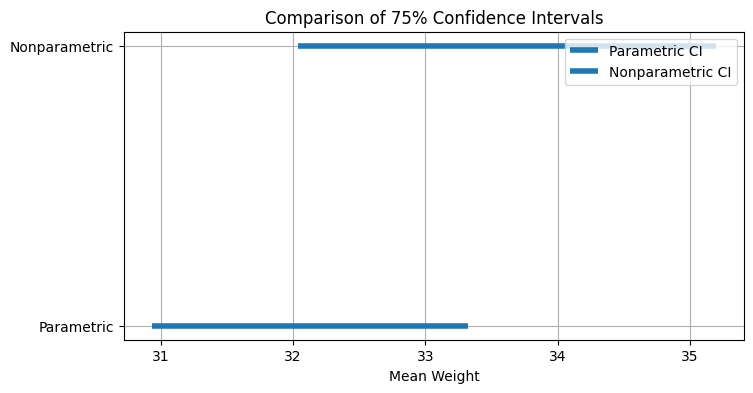

In [6]:
plt.figure(figsize=(8, 4))

# Plot intervals as horizontal lines
plt.hlines(y=1, xmin=lower_param, xmax=upper_param, linewidth=4, label="Parametric CI")
plt.hlines(y=2, xmin=lower_nonparam, xmax=upper_nonparam, linewidth=4, label="Nonparametric CI")

# Labels
plt.yticks([1, 2], ["Parametric", "Nonparametric"])
plt.xlabel("Mean Weight")
plt.title("Comparison of 75% Confidence Intervals")

plt.legend()
plt.grid()

plt.show()